In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor


##  Load Dataset

In [2]:
df = pd.read_csv('solar_weather - solar_weather.csv')

In [3]:
df.head()

,Time,Energy delta[Wh],GHI,temp,pressure,humidity,wind_speed,rain_1h,snow_1h,clouds_all,isSun,sunlightTime,dayLength,SunlightTime/daylength,weather_type,hour,month
0,2017-01-01 0:00:00,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0,1
1,2017-01-01 0:15:00,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0,1
2,2017-01-01 0:30:00,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0,1
3,2017-01-01 0:45:00,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0,1
4,2017-01-01 1:00:00,0,0.0,1.7,1020,100,5.2,0.0,0.0,100,0,0,450,0.0,4,1,1


In [4]:
df.tail()

,Time,Energy delta[Wh],GHI,temp,pressure,humidity,wind_speed,rain_1h,snow_1h,clouds_all,isSun,sunlightTime,dayLength,SunlightTime/daylength,weather_type,hour,month
196771,2022-08-31 16:45:00,118,23.7,18.6,1023,57,3.8,0.0,0.0,52,1,780,825,0.95,3,16,8
196772,2022-08-31 17:00:00,82,15.6,18.5,1023,61,4.2,0.0,0.0,60,1,795,825,0.96,3,17,8
196773,2022-08-31 17:15:00,51,8.0,18.5,1023,61,4.2,0.0,0.0,60,1,810,825,0.98,3,17,8
196774,2022-08-31 17:30:00,24,2.1,18.5,1023,61,4.2,0.0,0.0,60,1,825,825,1.00,3,17,8
196775,2022-08-31 17:45:00,0,0.0,18.5,1023,61,4.2,0.0,0.0,60,0,0,825,0.00,3,17,8


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196776 entries, 0 to 196775
Data columns (total 17 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Time                    196776 non-null  object 
 1   Energy delta[Wh]        196776 non-null  int64  
 2   GHI                     196776 non-null  float64
 3   temp                    196776 non-null  float64
 4   pressure                196776 non-null  int64  
 5   humidity                196776 non-null  int64  
 6   wind_speed              196776 non-null  float64
 7   rain_1h                 196776 non-null  float64
 8   snow_1h                 196776 non-null  float64
 9   clouds_all              196776 non-null  int64  
 10  isSun                   196776 non-null  int64  
 11  sunlightTime            196776 non-null  int64  
 12  dayLength               196776 non-null  int64  
 13  SunlightTime/daylength  196776 non-null  float64
 14  weather_type        

In this dataset we notice there are almost 17 columns where most of the data contains floating datatypes where 10 are int and rest of them are object

In [6]:
df.describe()   

,Energy delta[Wh],GHI,temp,pressure,humidity,wind_speed,rain_1h,snow_1h,clouds_all,isSun,sunlightTime,dayLength,SunlightTime/daylength,weather_type,hour,month
count,196776.000000,196776.000000,196776.000000,196776.000000,196776.000000,196776.000000,196776.000000,196776.000000,196776.000000,196776.000000,196776.000000,196776.000000,196776.000000,196776.000000,196776.000000,196776.000000
mean,573.008228,32.596538,9.790521,1015.292780,79.810566,3.937746,0.066035,0.007148,65.974387,0.519962,211.721094,748.644347,0.265187,3.198398,11.498902,6.298329
std,1044.824047,52.172018,7.995428,9.585773,15.604459,1.821694,0.278913,0.069710,36.628593,0.499603,273.902186,194.870208,0.329023,1.289939,6.921887,3.376066
min,0.000000,0.000000,-16.600000,977.000000,22.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,450.000000,0.000000,1.000000,0.000000,1.000000
25%,0.000000,0.000000,3.600000,1010.000000,70.000000,2.600000,0.000000,0.000000,34.000000,0.000000,0.000000,570.000000,0.000000,2.000000,5.000000,3.000000
50%,0.000000,1.600000,9.300000,1016.000000,84.000000,3.700000,0.000000,0.000000,82.000000,1.000000,30.000000,765.000000,0.050000,4.000000,11.000000,6.000000
75%,577.000000,46.800000,15.700000,1021.000000,92.000000,5.000000,0.000000,0.000000,100.000000,1.000000,390.000000,930.000000,0.530000,4.000000,17.000000,9.000000
max,5020.000000,229.200000,35.800000,1047.000000,100.000000,14.300000,8.090000,2.820000,100.000000,1.000000,1020.000000,1020.000000,1.000000,5.000000,23.000000,12.000000


In [7]:
df.shape

(196776, 17)

In [8]:
df.columns

Index(['Time', 'Energy delta[Wh]', 'GHI', 'temp', 'pressure', 'humidity',
       'wind_speed', 'rain_1h', 'snow_1h', 'clouds_all', 'isSun',
       'sunlightTime', 'dayLength', 'SunlightTime/daylength', 'weather_type',
       'hour', 'month'],
      dtype='object')

## Exploratory Data Analysis

In [9]:
df.isna().sum()

Time                      0
Energy delta[Wh]          0
GHI                       0
temp                      0
pressure                  0
humidity                  0
wind_speed                0
rain_1h                   0
snow_1h                   0
clouds_all                0
isSun                     0
sunlightTime              0
dayLength                 0
SunlightTime/daylength    0
weather_type              0
hour                      0
month                     0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

## Visualization

1. Target Distribution 

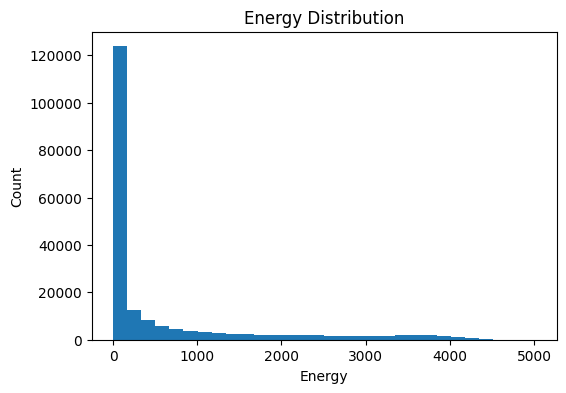

In [11]:
# 1. Energy Distribution
plt.figure(figsize=(6,4))
plt.hist(df["Energy delta[Wh]"], bins=30)
plt.title("Energy Distribution")
plt.xlabel("Energy")
plt.ylabel("Count")
plt.show()

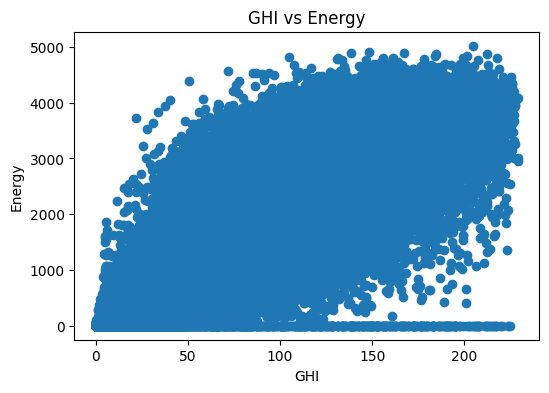

In [12]:
plt.figure(figsize=(6,4))
plt.scatter(df["GHI"], df["Energy delta[Wh]"])
plt.title("GHI vs Energy")
plt.xlabel("GHI")
plt.ylabel("Energy")
plt.show()


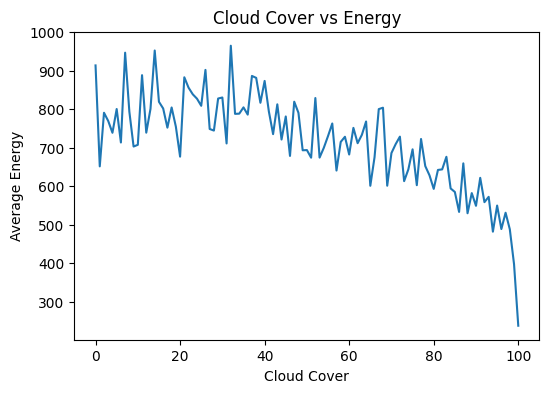

In [13]:
cloud = df.groupby("clouds_all")["Energy delta[Wh]"].mean()

plt.figure(figsize=(6,4))
plt.plot(cloud.index, cloud.values)
plt.title("Cloud Cover vs Energy")
plt.xlabel("Cloud Cover")
plt.ylabel("Average Energy")
plt.show()

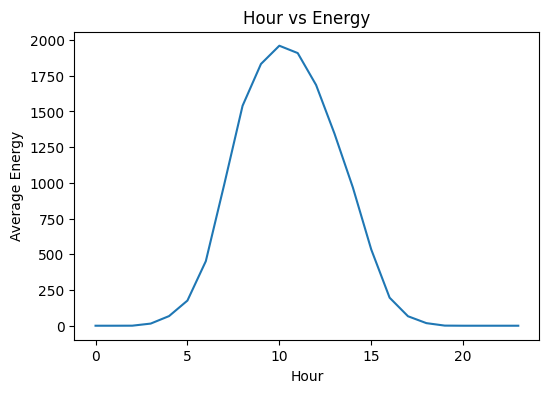

In [14]:
# 4. Hour vs Energy
hour = df.groupby("hour")["Energy delta[Wh]"].mean()

plt.figure(figsize=(6,4))
plt.plot(hour.index, hour.values)
plt.title("Hour vs Energy")
plt.xlabel("Hour")
plt.ylabel("Average Energy")
plt.show()

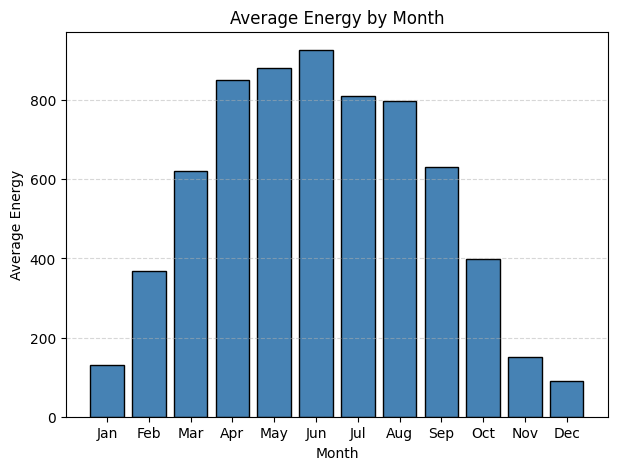

In [15]:
# 5. Month vs Energy
month = df.groupby("month")["Energy delta[Wh]"].mean()

plt.figure(figsize=(7,5))

plt.bar(
    month.index,
    month.values,
    color="steelblue",
    edgecolor="black"
)

plt.title("Average Energy by Month")
plt.xlabel("Month")
plt.ylabel("Average Energy")

plt.xticks(range(1,13),
           ["Jan","Feb","Mar","Apr","May","Jun",
            "Jul","Aug","Sep","Oct","Nov","Dec"])

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

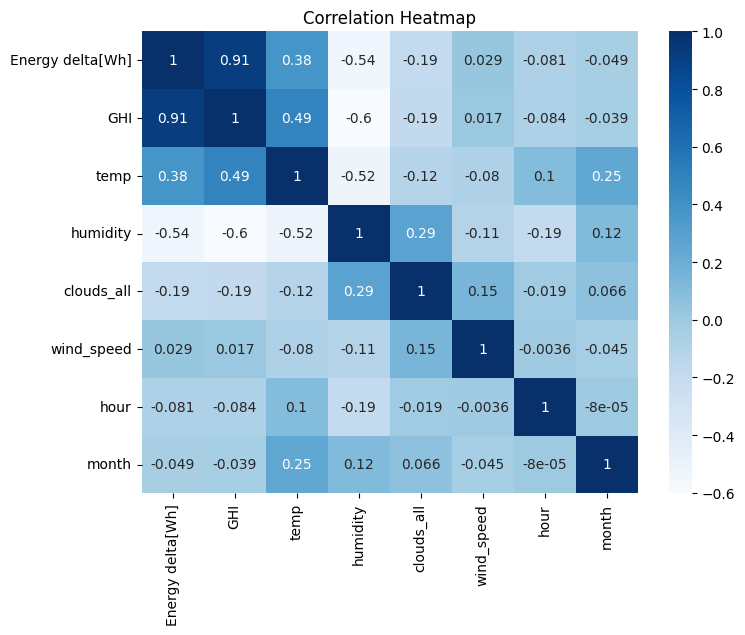

In [16]:
# 6. Correlation Heatmap
corr = df[["Energy delta[Wh]","GHI","temp","humidity","clouds_all","wind_speed","hour","month"]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True,cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()

## Outlier Detection

IQR Outliers : 30881
Z-Score Outliers : 5271


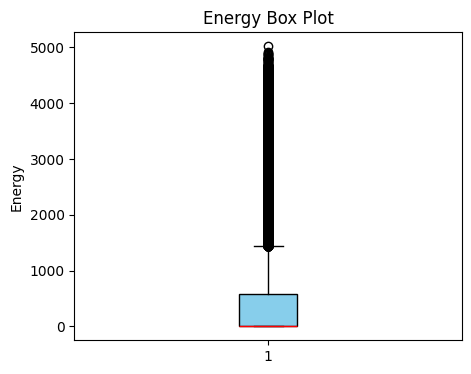

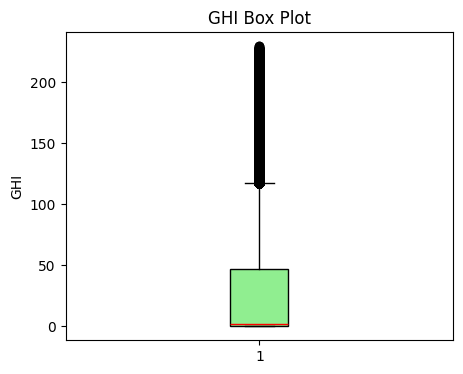

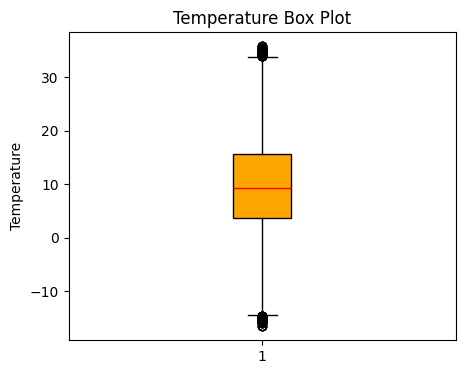

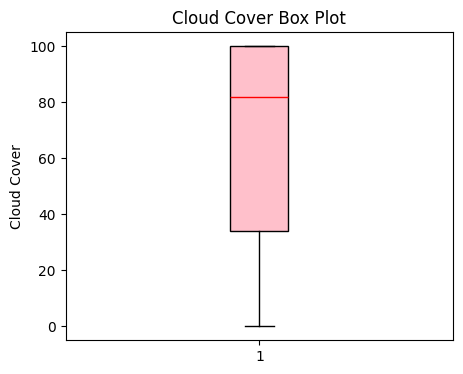

In [17]:
# IQR Method
Q1 = df["Energy delta[Wh]"].quantile(0.25)
Q3 = df["Energy delta[Wh]"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["Energy delta[Wh]"] < lower) | (df["Energy delta[Wh]"] > upper)]

print("IQR Outliers :", len(outliers))


# Z-Score Method
z_score = np.abs(stats.zscore(df["Energy delta[Wh]"]))

print("Z-Score Outliers :", (z_score > 3).sum())


# Box Plot - Energy
plt.figure(figsize=(5,4))

plt.boxplot(
    df["Energy delta[Wh]"].dropna(),
    patch_artist=True,
    boxprops=dict(facecolor="skyblue"),
    medianprops=dict(color="red")
)

plt.title("Energy Box Plot")
plt.ylabel("Energy")

plt.show()


# Box Plot - GHI
plt.figure(figsize=(5,4))

plt.boxplot(
    df["GHI"].dropna(),
    patch_artist=True,
    boxprops=dict(facecolor="lightgreen"),
    medianprops=dict(color="red")
)

plt.title("GHI Box Plot")
plt.ylabel("GHI")

plt.show()


# Box Plot - Temperature
plt.figure(figsize=(5,4))

plt.boxplot(
    df["temp"].dropna(),
    patch_artist=True,
    boxprops=dict(facecolor="orange"),
    medianprops=dict(color="red")
)

plt.title("Temperature Box Plot")
plt.ylabel("Temperature")

plt.show()


# Box Plot - Cloud Cover
plt.figure(figsize=(5,4))

plt.boxplot(
    df["clouds_all"].dropna(),
    patch_artist=True,
    boxprops=dict(facecolor="pink"),
    medianprops=dict(color="red")
)

plt.title("Cloud Cover Box Plot")
plt.ylabel("Cloud Cover")

plt.show()

## Feature Engineering

In [18]:
# Copy Dataset
new_df = df.copy()

# Effective GHI
new_df["new_GHI"] = new_df["GHI"] * (1 - new_df["clouds_all"] / 100)

# Hour Features
new_df["hour1"] = np.sin(2 * np.pi * new_df["hour"] / 24)
new_df["hour2"] = np.cos(2 * np.pi * new_df["hour"] / 24)

# Month Features
new_df["month1"] = np.sin(2 * np.pi * new_df["month"] / 12)
new_df["month2"] = np.cos(2 * np.pi * new_df["month"] / 12)

# Peak Hour
new_df["peak"] = (new_df["hour"] >= 10) & (new_df["hour"] <= 14)
new_df["peak"] = new_df["peak"].astype(int)

# Show New Features
print(new_df[[
    "new_GHI",
    "hour1",
    "hour2",
    "month1",
    "month2",
    "peak"
]].describe())

             new_GHI         hour1         hour2        month1        month2  \
count  196776.000000  1.967760e+05  1.967760e+05  1.967760e+05  1.967760e+05   
mean       14.698435  8.736588e-05 -6.703820e-05  2.745637e-02 -4.449917e-02   
std        35.676389  7.071014e-01  7.071158e-01  7.068126e-01  7.054693e-01   
min         0.000000 -1.000000e+00 -1.000000e+00 -1.000000e+00 -1.000000e+00   
25%         0.000000 -7.071068e-01 -7.071068e-01 -5.000000e-01 -8.660254e-01   
50%         0.000000  1.224647e-16 -1.836970e-16  1.224647e-16 -1.836970e-16   
75%         5.710500  7.071068e-01  7.071068e-01  8.660254e-01  5.000000e-01   
max       227.300000  1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00   

                peak  
count  196776.000000  
mean        0.208359  
std         0.406136  
min         0.000000  
25%         0.000000  
50%         0.000000  
75%         0.000000  
max         1.000000  


# Data Preparation and Train_Test split

In [19]:
# Input and Output

X = new_df[[
    "GHI",
    "temp",
    "pressure",
    "humidity",
    "wind_speed",
    "rain_1h",
    "clouds_all",
    "isSun",
    "sunlightTime",
    "hour",
    "month"
]]

y = new_df["Energy delta[Wh]"]


# Missing Value
X = X.fillna(0)


# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# Shape
print("Training Data :", X_train.shape)
print("Testing Data  :", X_test.shape)

Training Data : (157420, 11)
Testing Data  : (39356, 11)


# Model Train and Comparison

In [20]:
# Linear Regression 
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Linear Regression Performance")
print("Mean Squared Error :", mean_squared_error(y_test, lr_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, lr_pred))
print("R2 Score           :", r2_score(y_test, lr_pred))


Linear Regression Performance
Mean Squared Error : 165146.83351906063
Mean Absolute Error: 227.9494564575793
R2 Score           : 0.8501317366165909


In [21]:
#  Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Regressor Performance")
print("Mean Squared Error :", mean_squared_error(y_test, rf_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, rf_pred))
print("R2 Score           :", r2_score(y_test, rf_pred))

Random Forest Regressor Performance
Mean Squared Error : 71992.0111912288
Mean Absolute Error: 109.49457261916862
R2 Score           : 0.9346683344463692


In [22]:
# XGBoost Regressor

xgboost = XGBRegressor(n_estimators=100, random_state=42)

xgboost.fit(X_train, y_train)

xgboost_pred = xgboost.predict(X_test)

print("XGBoost Regressor Performance")
print("Mean Squared Error :", mean_squared_error(y_test, xgboost_pred)) 
print("R2 Score           :", r2_score(y_test, xgboost_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, xgboost_pred))

XGBoost Regressor Performance
Mean Squared Error : 75586.4453125
R2 Score           : 0.9314064383506775
Mean Absolute Error: 119.6263198852539


# Model Comparison

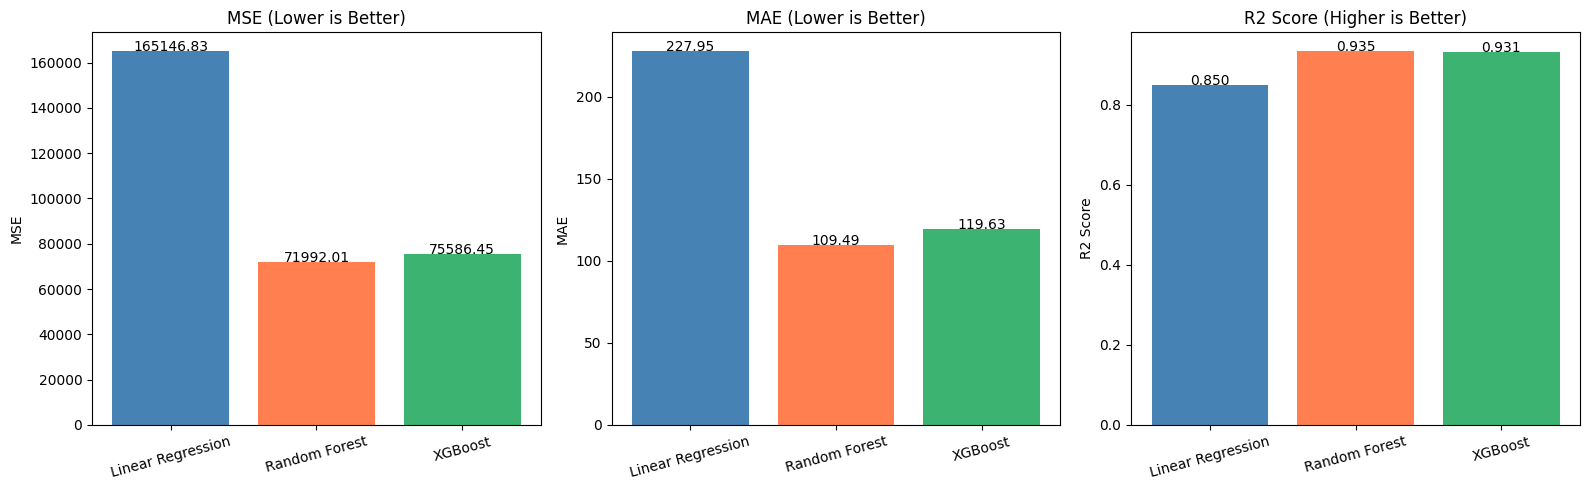

In [23]:
models = ["Linear Regression", "Random Forest", "XGBoost"]

mse = [
    mean_squared_error(y_test, lr_pred),
    mean_squared_error(y_test, rf_pred),
    mean_squared_error(y_test, xgboost_pred)
]

mae = [
    mean_absolute_error(y_test, lr_pred),
    mean_absolute_error(y_test, rf_pred),
    mean_absolute_error(y_test, xgboost_pred)
]

r2 = [
    r2_score(y_test, lr_pred),
    r2_score(y_test, rf_pred),
    r2_score(y_test, xgboost_pred)
]

x = np.arange(len(models))
colors = ["steelblue", "coral", "mediumseagreen"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# MSE
axes[0].bar(x, mse, color=colors)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=15)
axes[0].set_title("MSE (Lower is Better)")
axes[0].set_ylabel("MSE")

for i, v in enumerate(mse):
    axes[0].text(i, v, f"{v:.2f}", ha="center")


# MAE
axes[1].bar(x, mae, color=colors)
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=15)
axes[1].set_title("MAE (Lower is Better)")
axes[1].set_ylabel("MAE")

for i, v in enumerate(mae):
    axes[1].text(i, v, f"{v:.2f}", ha="center")


# R2 Score
axes[2].bar(x, r2, color=colors)
axes[2].set_xticks(x)
axes[2].set_xticklabels(models, rotation=15)
axes[2].set_title("R2 Score (Higher is Better)")
axes[2].set_ylabel("R2 Score")

for i, v in enumerate(r2):
    axes[2].text(i, v, f"{v:.3f}", ha="center")

plt.tight_layout()
plt.show()

# Best Model Selection

Best Model : Random Forest
Mean Squared Error : 71992.0111912288
Mean Absolute Error: 109.49457261916862
R2 Score           : 0.9346683344463692


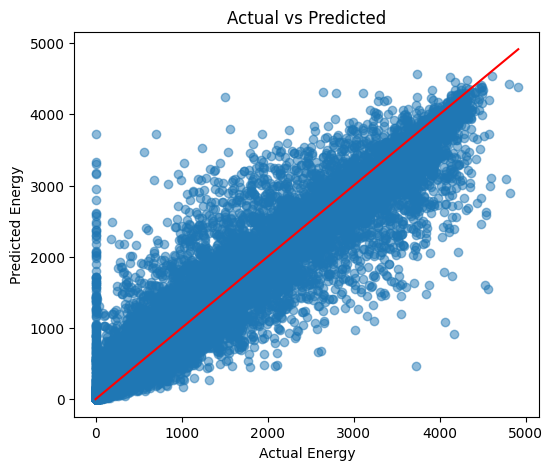

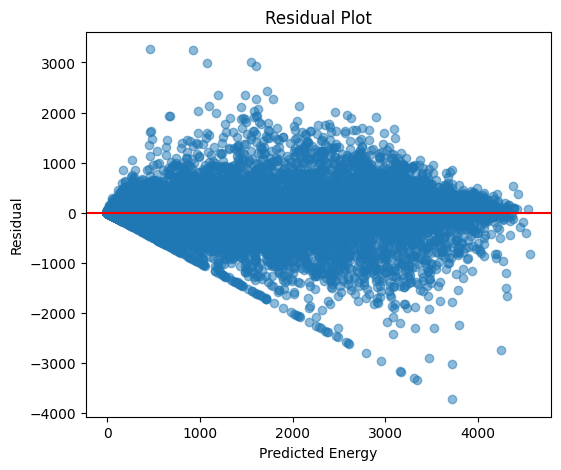

In [24]:

print("Best Model : Random Forest")

print("Mean Squared Error :", mean_squared_error(y_test, rf_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, rf_pred))
print("R2 Score           :", r2_score(y_test, rf_pred))


# Actual vs Predicted
plt.figure(figsize=(6,5))

plt.scatter(y_test, rf_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.title("Actual vs Predicted")
plt.xlabel("Actual Energy")
plt.ylabel("Predicted Energy")

plt.show()


# Residual Plot
residual = y_test - rf_pred

plt.figure(figsize=(6,5))

plt.scatter(rf_pred, residual, alpha=0.5)

plt.axhline(y=0, color="red")

plt.title("Residual Plot")
plt.xlabel("Predicted Energy")
plt.ylabel("Residual")

plt.show()

# Feature Importance

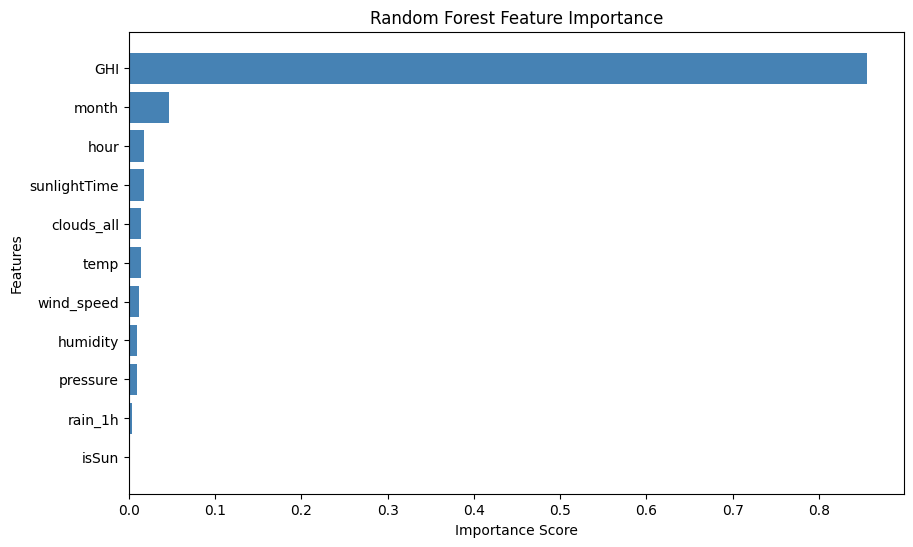

Top 5 Important Features
GHI             0.855560
month           0.046164
hour            0.018022
sunlightTime    0.017963
clouds_all      0.014227
dtype: float64


In [25]:

importance = rf.feature_importances_

feature_importance = pd.Series(importance, index=X.columns)

feature_importance = feature_importance.sort_values()

plt.figure(figsize=(10, 6))

plt.barh(feature_importance.index, feature_importance.values, color="steelblue")

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()


print("Top 5 Important Features")
print(feature_importance.sort_values(ascending=False).head())

In [27]:
import pickle

with open("random_forest_model.pkl", "wb") as file:
    pickle.dump(rf, file)

print("Model saved successfully!")

Model saved successfully!
